# Validate USDC Prices Against CoinGecko

Compare our calculated swap-derived USDC prices against CoinGecko historical data for selected tokens.


In [1]:
import os
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import polars as pl
import requests
from dotenv import load_dotenv

load_dotenv()

# CoinGecko API key
COINGECKO_API_KEY = os.getenv("COINGECKO_API_KEY")

# USDC address for reference
USDC_ADDRESS = "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48"

# Known token addresses and their CoinGecko IDs
# Note: Addresses are verified against CoinGecko API and our swap data
TOKENS_TO_VALIDATE = {
    "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2": {
        "name": "WETH",
        "coingecko_id": "weth",
    },
    "0xdac17f958d2ee523a2206206994597c13d831ec7": {
        "name": "USDT",
        "coingecko_id": "tether",
    },
    "0x2260fac5e5542a773aa44fbcfedf7c193bc2c599": {
        "name": "WBTC",
        "coingecko_id": "wrapped-bitcoin",
    },
    "0x6b175474e89094c44da98b954eedeac495271d0f": {
        "name": "DAI",
        "coingecko_id": "dai",
    },
    "0x514910771af9ca656af840dff83e8264ecf986ca": {
        "name": "LINK",
        "coingecko_id": "chainlink",
    },
}

print("Setup complete!")

Setup complete!


In [2]:
# Load our calculated prices
df_prices = pl.read_parquet("data/usdc_prices_timeseries.parquet")

print(f"Loaded {len(df_prices):,} price observations")
print(f"Start: {df_prices['block_timestamp'].min()}")
print(f"End: {df_prices['block_timestamp'].max()}")
print(f"\nUnique tokens: {df_prices['token_address'].n_unique()}")

# Load the original USDC-paired swaps to check USDC coverage
df_swaps = pl.read_parquet("data/usdc_paired_swaps.parquet")

# Count swaps with USDC as token0 or token1
swaps_with_usdc = df_swaps.filter(
    (pl.col("token0") == USDC_ADDRESS) | (pl.col("token1") == USDC_ADDRESS),
)

# Count swaps between two non-USDC tokens (these can still be in dataset if both tokens have USDC pools)
swaps_without_usdc = df_swaps.filter(
    (pl.col("token0") != USDC_ADDRESS) & (pl.col("token1") != USDC_ADDRESS),
)

print("\n" + "=" * 70)
print("USDC SWAP COVERAGE ANALYSIS")
print("=" * 70)
print(f"Total swaps in dataset: {len(df_swaps):,}")
print(
    f"Swaps with USDC (token0 or token1): {len(swaps_with_usdc):,} ({len(swaps_with_usdc) / len(df_swaps) * 100:.2f}%)",
)
print(
    f"Swaps between non-USDC tokens: {len(swaps_without_usdc):,} ({len(swaps_without_usdc) / len(df_swaps) * 100:.2f}%)"
)
print()
print("Breakdown:")
print(f"  USDC as token0: {len(df_swaps.filter(pl.col('token0') == USDC_ADDRESS)):,}")
print(f"  USDC as token1: {len(df_swaps.filter(pl.col('token1') == USDC_ADDRESS)):,}")
print("=" * 70)

Loaded 4,015,145 price observations
Start: 2025-07-01 00:00:11+00:00
End: 2025-09-01 23:59:59+00:00

Unique tokens: 196

USDC SWAP COVERAGE ANALYSIS
Total swaps in dataset: 4,887,932
Swaps with USDC (token0 or token1): 1,868,770 (38.23%)
Swaps between non-USDC tokens: 3,019,162 (61.77%)

Breakdown:
  USDC as token0: 1,388,114
  USDC as token1: 480,656


In [3]:
def fetch_coingecko_prices(token_id: str, start_date: str, end_date: str) -> dict:
    """Fetch historical prices from CoinGecko API with caching.

    Args:
        token_id: CoinGecko token ID (e.g., 'weth')
        start_date: Start date in YYYY-MM-DD format
        end_date: End date in YYYY-MM-DD format

    Returns:
        Polars DataFrame with timestamps and prices in USD
    """
    # Create cache directory if it doesn't exist
    cache_dir = "data/prices"
    os.makedirs(cache_dir, exist_ok=True)

    # Create cache filename based on token_id and date range
    cache_file = os.path.join(cache_dir, f"{token_id}_{start_date}_{end_date}.parquet")

    # Check if cached file exists
    if os.path.exists(cache_file):
        print(f"  Loading from cache: {cache_file}")
        return pl.read_parquet(cache_file)

    print(f"  Fetching from CoinGecko API...")

    # Convert dates to timestamps
    start_ts = int(
        datetime.strptime(start_date, "%Y-%m-%d")
        .replace(tzinfo=timezone.utc)
        .timestamp()
    )
    end_ts = int(
        datetime.strptime(end_date, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp()
    )

    # Use standard API endpoint with Demo API key header
    url = f"https://api.coingecko.com/api/v3/coins/{token_id}/market_chart/range"
    params = {
        "vs_currency": "usd",
        "from": start_ts,
        "to": end_ts,
    }
    headers = {
        "x-cg-demo-api-key": COINGECKO_API_KEY,  # Demo API key uses this header
    }

    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()

    data = response.json()
    prices = data.get("prices", [])

    # Convert to polars DataFrame
    df = pl.DataFrame(
        {
            "timestamp": [
                datetime.fromtimestamp(p[0] / 1000, tz=timezone.utc) for p in prices
            ],
            "price_usd": [p[1] for p in prices],
        }
    )

    # Cache the results
    df.write_parquet(cache_file)
    print(f"  Cached to: {cache_file}")

    return df


print("Helper function defined!")

Helper function defined!


In [4]:
# Fetch CoinGecko prices for validation tokens
coingecko_prices = {}

for address, info in TOKENS_TO_VALIDATE.items():
    print(f"Fetching {info['name']} prices from CoinGecko...")
    try:
        df_cg = fetch_coingecko_prices(info["coingecko_id"], "2025-07-01", "2025-09-01")
        coingecko_prices[address] = df_cg
        print(f"  Got {len(df_cg)} price points")
    except Exception as e:
        print(f"  Error: {e}")

print("\nDone fetching CoinGecko prices!")

Fetching WETH prices from CoinGecko...
  Loading from cache: data/prices/weth_2025-07-01_2025-09-01.parquet
  Got 1489 price points
Fetching USDT prices from CoinGecko...
  Loading from cache: data/prices/tether_2025-07-01_2025-09-01.parquet
  Got 1489 price points
Fetching WBTC prices from CoinGecko...
  Loading from cache: data/prices/wrapped-bitcoin_2025-07-01_2025-09-01.parquet
  Got 1488 price points
Fetching DAI prices from CoinGecko...
  Loading from cache: data/prices/dai_2025-07-01_2025-09-01.parquet
  Got 1489 price points
Fetching LINK prices from CoinGecko...
  Loading from cache: data/prices/chainlink_2025-07-01_2025-09-01.parquet
  Got 1489 price points

Done fetching CoinGecko prices!



Plot saved to ../data/price_validation.png


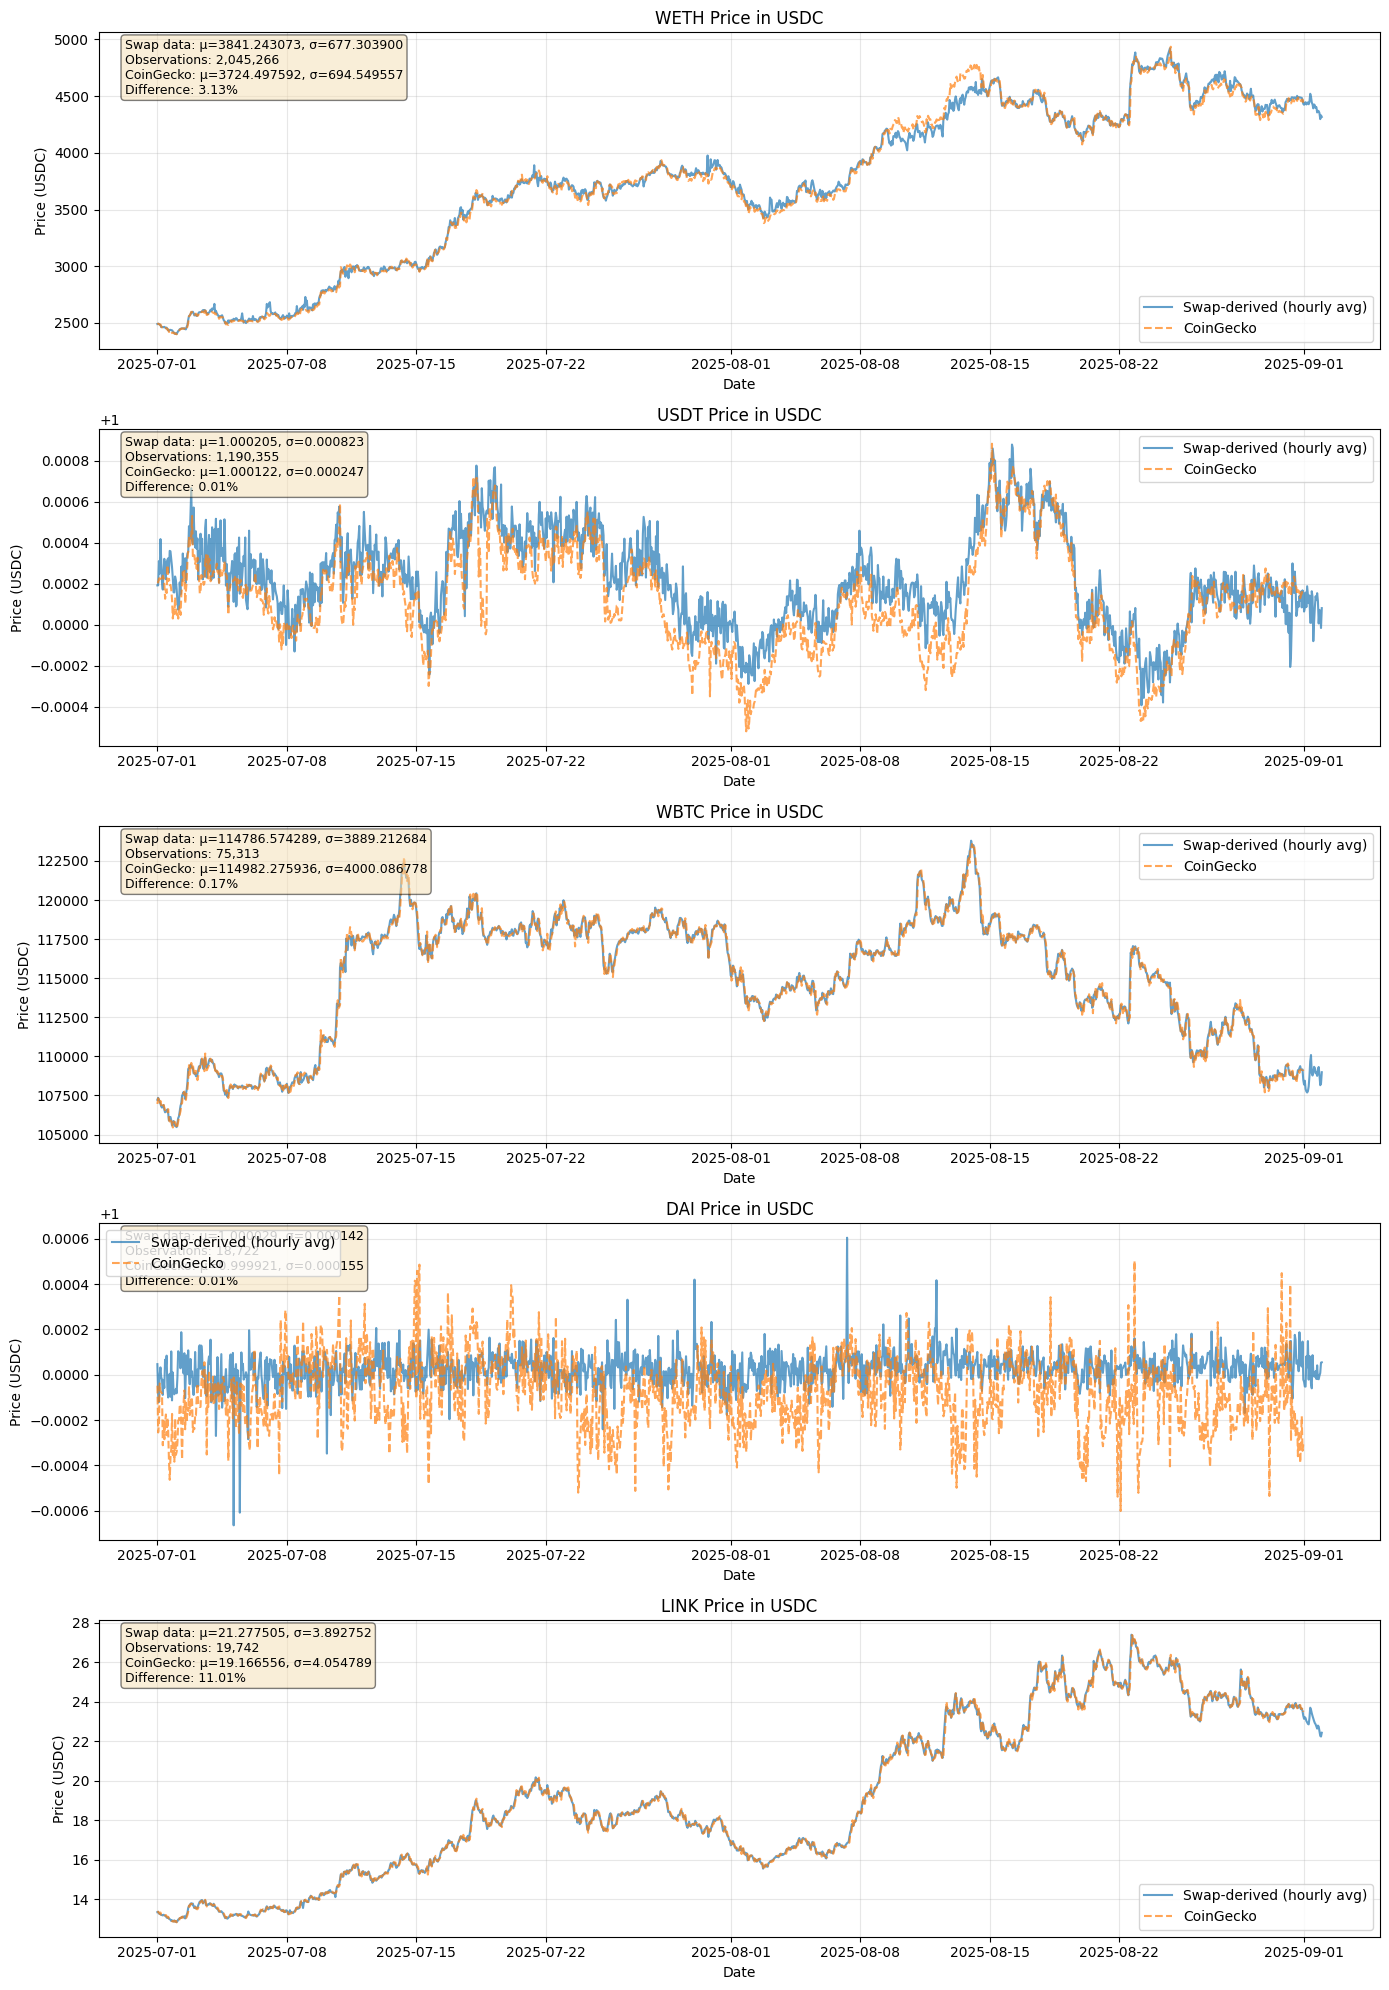

In [5]:
# Plot comparison for each token
fig, axes = plt.subplots(
    len(TOKENS_TO_VALIDATE), 1, figsize=(14, 4 * len(TOKENS_TO_VALIDATE))
)

if len(TOKENS_TO_VALIDATE) == 1:
    axes = [axes]

for idx, (address, info) in enumerate(TOKENS_TO_VALIDATE.items()):
    ax = axes[idx]
    token_name = info["name"]

    # Get our calculated prices for this token
    df_our_prices = df_prices.filter(pl.col("token_address") == address)

    if len(df_our_prices) == 0:
        ax.set_title(f"{token_name} - No swap data available")
        continue

    # Resample to hourly for cleaner visualization
    df_hourly = (
        df_our_prices.sort("block_timestamp")
        .group_by_dynamic("block_timestamp", every="1h")
        .agg(
            [
                pl.col("price_in_usdc").mean().alias("price_mean"),
                pl.col("usdc_volume").sum().alias("volume"),
            ]
        )
    )

    # Plot our prices
    ax.plot(
        df_hourly["block_timestamp"].to_list(),
        df_hourly["price_mean"].to_list(),
        label="Swap-derived (hourly avg)",
        alpha=0.7,
        linewidth=1.5,
    )

    # Plot CoinGecko prices if available
    if address in coingecko_prices:
        df_cg = coingecko_prices[address]
        ax.plot(
            df_cg["timestamp"].to_list(),
            df_cg["price_usd"].to_list(),
            label="CoinGecko",
            alpha=0.7,
            linewidth=1.5,
            linestyle="--",
        )

    ax.set_title(f"{token_name} Price in USDC")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USDC)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add summary statistics
    swap_mean = df_our_prices["price_in_usdc"].mean()
    swap_std = df_our_prices["price_in_usdc"].std()
    text = f"Swap data: μ={swap_mean:.6f}, σ={swap_std:.6f}\n"
    text += f"Observations: {len(df_our_prices):,}"

    if address in coingecko_prices:
        cg_mean = coingecko_prices[address]["price_usd"].mean()
        cg_std = coingecko_prices[address]["price_usd"].std()
        text += f"\nCoinGecko: μ={cg_mean:.6f}, σ={cg_std:.6f}"
        text += f"\nDifference: {abs(swap_mean - cg_mean) / cg_mean * 100:.2f}%"

    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.savefig("../data/price_validation.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to ../data/price_validation.png")
plt.show()

NOTE: See STABLECOIN_VALIDATOIN_FINDINGS to interpret these values and the charts above


In [6]:
# Calculate correlation and error metrics
print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

for address, info in TOKENS_TO_VALIDATE.items():
    token_name = info["name"]

    df_our = df_prices.filter(pl.col("token_address") == address)

    if len(df_our) == 0 or address not in coingecko_prices:
        continue

    # Resample both to hourly and join
    df_our_hourly = (
        df_our.sort("block_timestamp")
        .group_by_dynamic("block_timestamp", every="1h")
        .agg(pl.col("price_in_usdc").mean().alias("swap_price"))
        .with_columns(pl.col("block_timestamp").dt.truncate("1h").alias("hour"))
    )

    df_cg = coingecko_prices[address]
    df_cg_hourly = (
        df_cg.with_columns(pl.col("timestamp").dt.truncate("1h").alias("hour"))
        .group_by("hour")
        .agg(pl.col("price_usd").mean().alias("cg_price"))
    )

    # Join on hour
    df_joined = df_our_hourly.join(df_cg_hourly, on="hour", how="inner")

    if len(df_joined) > 0:
        # Calculate metrics
        correlation = df_joined.select(pl.corr("swap_price", "cg_price").alias("corr"))[
            "corr"
        ][0]

        # Mean absolute percentage error
        mape = (
            (df_joined["swap_price"] - df_joined["cg_price"]).abs()
            / df_joined["cg_price"]
        ).mean() * 100

        print(f"\n{token_name}:")
        print(f"  Correlation: {correlation:.4f}")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  Matched hours: {len(df_joined)}")


VALIDATION SUMMARY

WETH:
  Correlation: 0.9973
  MAPE: 0.86%
  Matched hours: 1488

USDT:
  Correlation: 0.9106
  MAPE: 0.01%
  Matched hours: 1488

WBTC:
  Correlation: 0.9975
  MAPE: 0.17%
  Matched hours: 1487

DAI:
  Correlation: 0.0494
  MAPE: 0.02%
  Matched hours: 1485

LINK:
  Correlation: 0.9994
  MAPE: 0.49%
  Matched hours: 1450
